<a href="https://colab.research.google.com/github/danhhuit/deep_learning_practice/blob/main/Labs04_AutoEncoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
from keras.datasets import mnist
import numpy as np
import keras
from keras import layers

In [13]:
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32')/255.
x_test = x_test.astype('float32')/255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:])))
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:])))
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [14]:
from keras import regularizers
encoding_dim = 32
input_img = keras.Input(shape=(784,))
#them l1
encoded = layers.Dense(encoding_dim, activity_regularizer=regularizers.l1(10e-5), activation='relu')(input_img)
de_coded = layers.Dense(784, activation='sigmoid')(encoded)
autoencoder = keras.Model(input_img, de_coded)
encoder = keras.Model(input_img, encoded)
encoded_input = keras.Input(shape=(encoding_dim,))
decoder_layer = autoencoder.layers[-1]
decoder = keras.Model(encoded_input, decoder_layer(encoded_input))

In [15]:
autoencoder.compile(optimizer='adam',loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.fit(x_train, x_train,
                # 50 => 100
                epochs=100,
                batch_size=256, verbose = 1,
                shuffle = True,
                validation_data = (x_test, x_test))

Epoch 1/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0144 - loss: 0.6550 - val_accuracy: 0.0161 - val_loss: 0.6156
Epoch 2/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.0144 - loss: 0.5833 - val_accuracy: 0.0161 - val_loss: 0.5535
Epoch 3/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.5275 - val_accuracy: 0.0161 - val_loss: 0.5038
Epoch 4/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.4827 - val_accuracy: 0.0161 - val_loss: 0.4638
Epoch 5/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.0150 - loss: 0.4466 - val_accuracy: 0.0161 - val_loss: 0.4314
Epoch 6/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.0150 - loss: 0.4174 - val_accuracy: 0.0161 - val_loss: 0.4050
Epoch 7/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0147 - loss: 0.3935 - val_accuracy: 0.0161 - val_loss: 0.3834
Epoch 8/100
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.0150 - loss: 0.3739 - 

In [16]:
encoded_imgs = encoder.predict(x_test)
decoded_imgs = decoder.predict(encoded_imgs)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


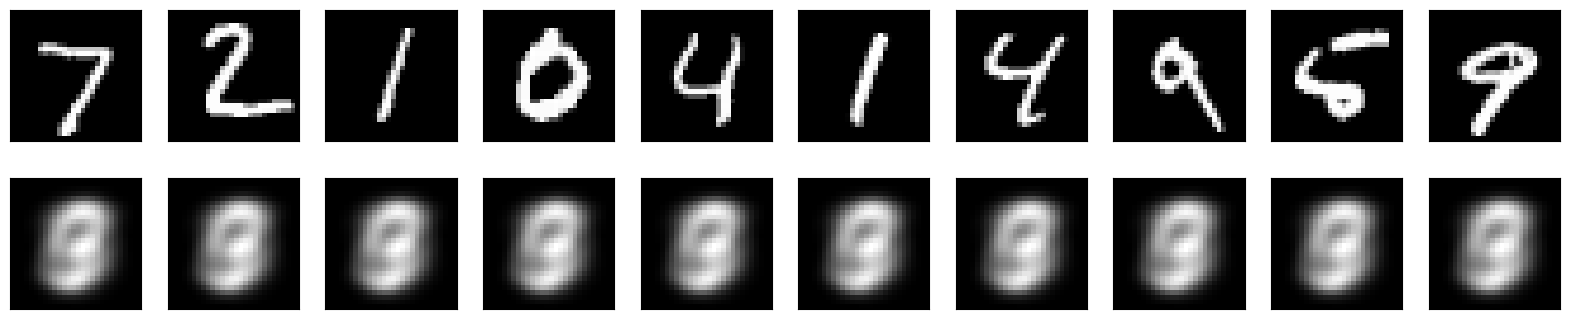

In [17]:
import matplotlib.pyplot as plt
n=10
plt.figure(figsize=(20,4))
for i in range(n):
  ax=plt.subplot(2, n, i+1)
  plt.imshow(x_test[i].reshape(28,28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)

  ax = plt.subplot(2, n, i+1+n)
  plt.imshow(decoded_imgs[i].reshape(28, 28))
  plt.gray()
  ax.get_xaxis().set_visible(False)
  ax.get_yaxis().set_visible(False)
plt.show()